<a href="https://colab.research.google.com/github/GOKULA-127/TEXTMINING-PROJECT/blob/main/TextMining3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


===== DATASET OVERVIEW =====
Total samples: 5000

Class Distribution:
gold_label
contradiction    1711
neutral          1645
entailment       1644
Name: count, dtype: int64


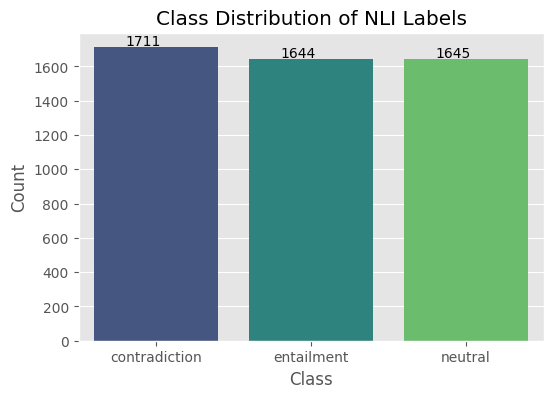


===== MODEL TRAINING =====
Logistic Regression → Accuracy: 0.3940, F1: 0.3942
Naive Bayes → Accuracy: 0.3940, F1: 0.3913
SVM → Accuracy: 0.3800, F1: 0.3806

===== RESULTS TABLE =====
                 Model  Accuracy  Precision  Recall  F1-score
0  Logistic Regression     0.394   0.396703   0.394  0.394217
1          Naive Bayes     0.394   0.400921   0.394  0.391276
2                  SVM     0.380   0.381908   0.380  0.380551

🔥 BEST MODEL: Logistic Regression


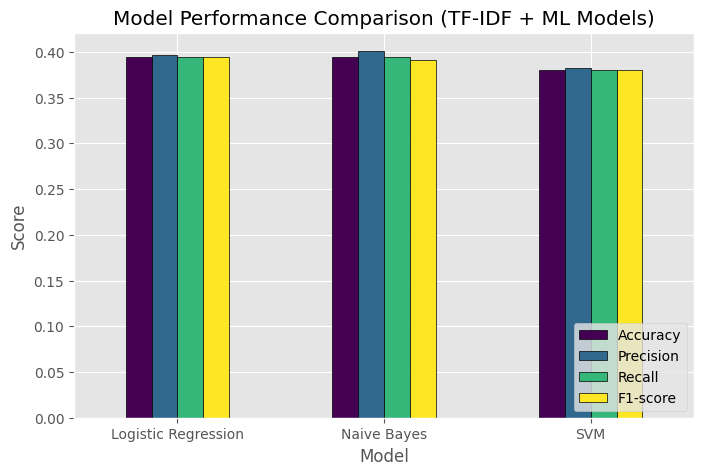

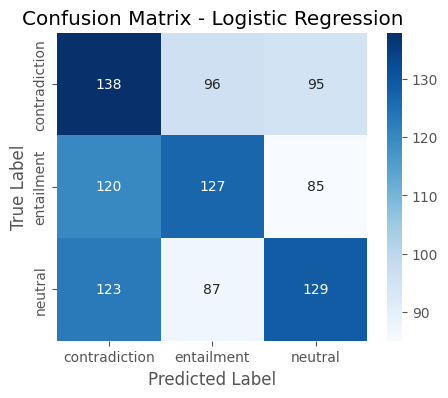


===== CLASSIFICATION REPORT =====
               precision    recall  f1-score   support

contradiction       0.36      0.42      0.39       329
   entailment       0.41      0.38      0.40       332
      neutral       0.42      0.38      0.40       339

     accuracy                           0.39      1000
    macro avg       0.40      0.39      0.39      1000
 weighted avg       0.40      0.39      0.39      1000



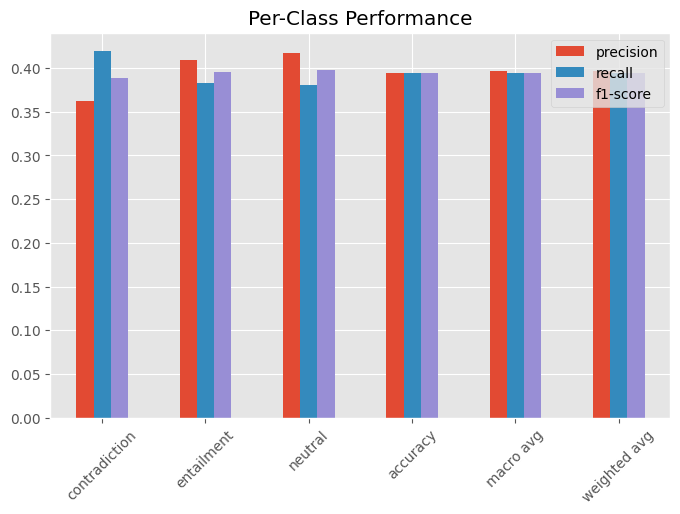

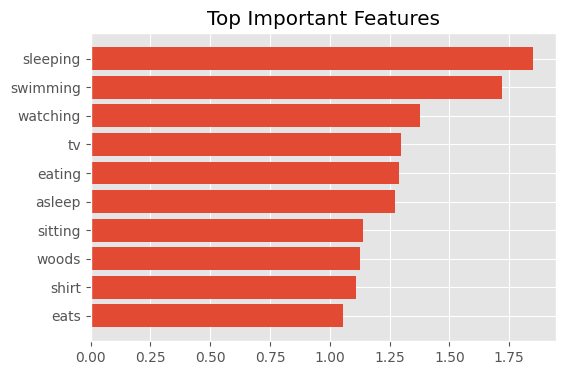


===== MISCLASSIFIED EXAMPLES =====
Text: A group of young boys in blue swimming suits attempt to jump into a pool to their swimming instructors. The boys are playing in the grass.
Actual: contradiction
Predicted: entailment
--------------------------------------------------
Text: A small, skinny, black child hanging on a piece of wood looking at a white woman. The child has his eyes closed.
Actual: entailment
Predicted: neutral
--------------------------------------------------
Text: A female in an orange sweatsuit walks down the street. A woman in an orange jumpsuit was released from jail.
Actual: contradiction
Predicted: neutral
--------------------------------------------------
Text: A boy in a blue shirt is blindfolded and holding a stick. boy holds stick
Actual: contradiction
Predicted: entailment
--------------------------------------------------
Text: A volleyball player on the beach sets up to take a shot that was just returned to her. The player about to return the ball is ti

In [ ]:
# ==============================
# 1. IMPORTS
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

plt.style.use('ggplot')

# ==============================
# 2. LOAD DATA
# ==============================
df = pd.read_csv("snli_data/snli_1.0/snli_1.0_train.txt", sep="\t")

df = df[['sentence1', 'sentence2', 'gold_label']]
df = df[df['gold_label'] != '-']

df['text'] = df['sentence1'] + " " + df['sentence2']

df = df.sample(5000, random_state=42).reset_index(drop=True)

# ==============================
# 3. DATASET OVERVIEW
# ==============================
print("\n===== DATASET OVERVIEW =====")
print("Total samples:", len(df))
print("\nClass Distribution:")
print(df['gold_label'].value_counts())

# ==============================
# 4. CLASS DISTRIBUTION (ENHANCED)
# ==============================
plt.figure(figsize=(6,4))
ax = sns.countplot(x=df['gold_label'], hue=df['gold_label'], palette="viridis", legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+0.2, p.get_height()+10))

plt.title("Class Distribution of NLI Labels")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# ==============================
# 5. TF-IDF (ENHANCED)
# ==============================
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words='english'
)

X = vectorizer.fit_transform(df['text'])
y = df['gold_label']

# ==============================
# 6. TRAIN TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 7. MODEL TRAINING
# ==============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC()
}

results = []

print("\n===== MODEL TRAINING =====")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    })

    print(f"{name} → Accuracy: {acc:.4f}, F1: {f1:.4f}")

# ==============================
# 8. RESULTS TABLE
# ==============================
results_df = pd.DataFrame(results)
print("\n===== RESULTS TABLE =====")
print(results_df)

# ==============================
# 9. BEST MODEL
# ==============================
best = results_df.loc[results_df['F1-score'].idxmax()]
print("\n🔥 BEST MODEL:", best['Model'])

# ==============================
# 10. MODEL COMPARISON (ADVANCED)
# ==============================
results_df.set_index("Model").plot(
    kind='bar',
    figsize=(8,5),
    colormap="viridis",
    edgecolor='black'
)

plt.title("Model Performance Comparison (TF-IDF + ML Models)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

# ==============================
# 11. CONFUSION MATRIX
# ==============================
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=np.unique(y),
            yticklabels=np.unique(y))

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ==============================
# 12. CLASSIFICATION REPORT
# ==============================
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

# ==============================
# 13. PER-CLASS PERFORMANCE (NEW)
# ==============================
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

report_df[['precision','recall','f1-score']].plot(kind='bar', figsize=(8,5))
plt.title("Per-Class Performance")
plt.xticks(rotation=45)
plt.show()

# ==============================
# 14. FEATURE IMPORTANCE
# ==============================
feature_names = vectorizer.get_feature_names_out()
coefficients = best_model.coef_[0]

top_words = np.argsort(coefficients)[-10:]

plt.figure(figsize=(6,4))
plt.barh([feature_names[i] for i in top_words], coefficients[top_words])
plt.title("Top Important Features")
plt.show()

# ==============================
# 15. ERROR ANALYSIS (NEW 🔥)
# ==============================
print("\n===== MISCLASSIFIED EXAMPLES =====")

misclassified = []

for i in range(len(y_test)):
    if y_test.iloc[i] != y_pred[i]:
        misclassified.append(i)

for i in misclassified[:5]:
    print("Text:", df.iloc[i]['text'])
    print("Actual:", y_test.iloc[i])
    print("Predicted:", y_pred[i])
    print("-"*50)

# ==============================
# 16. SAMPLE PREDICTIONS
# ==============================
print("\n===== SAMPLE PREDICTIONS =====")
for i in range(3):
    print("Text:", df.iloc[i]['text'])
    print("Actual:", df.iloc[i]['gold_label'])
    print("Predicted:", best_model.predict(X[i])[0])
    print("-"*50)

# ==============================
# 17. INSIGHT (FOR REPORT)
# ==============================
print("\nInsight:")
print("The model performs moderately due to lack of contextual understanding in TF-IDF. "
      "Better performance can be achieved using transformer-based models like BERT.")